# 1. Intro
* K_mean_clustering(Km) is one of the most basic algorithms of unsupervised learning.
* In the Km algorithm, we do not know the labels of each data point. The goal is to partition the data into different clusters such that the data points within the same cluster share similar characteristics.

Example 1:
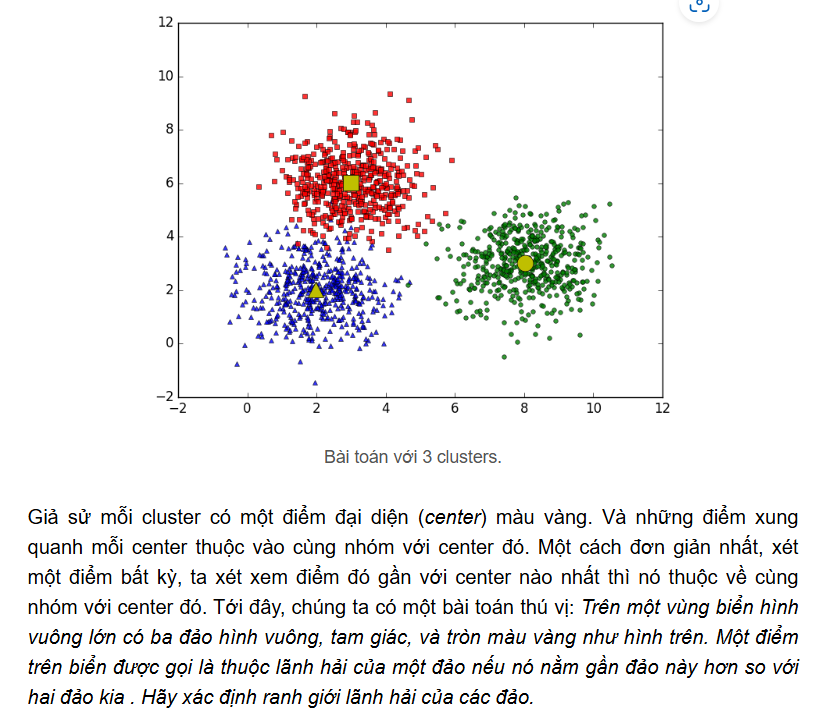

Example 2:
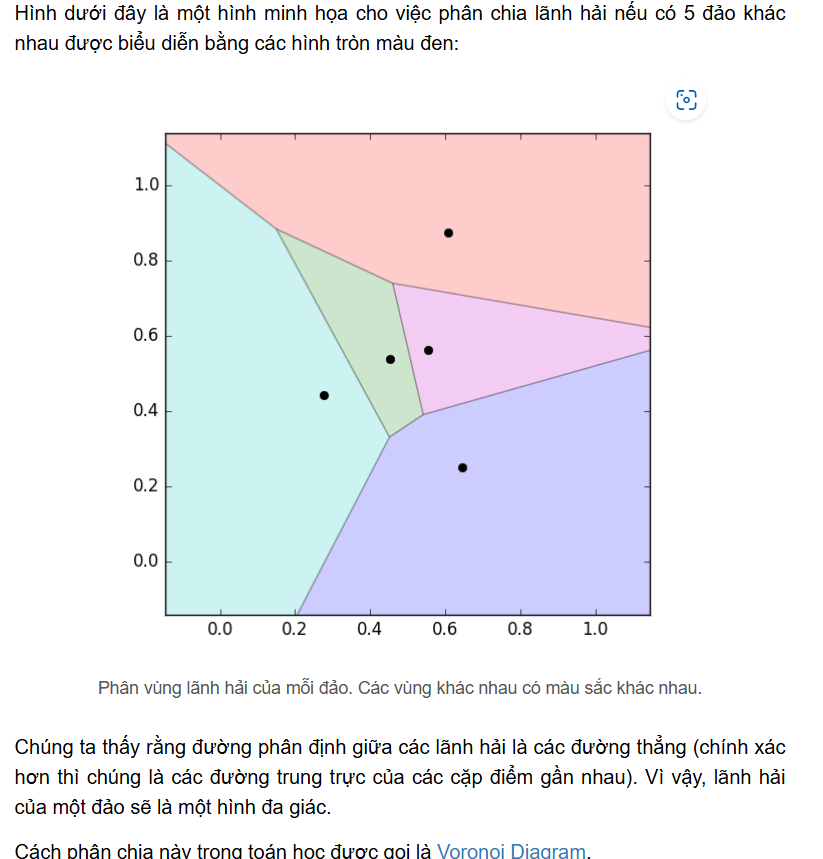

# 2. Theory - Solving mathematics problems

The ultimate goal of Km is to find center of each group from input data and number of group we want to find. Assume that each data point belongs to one distinct cluster.

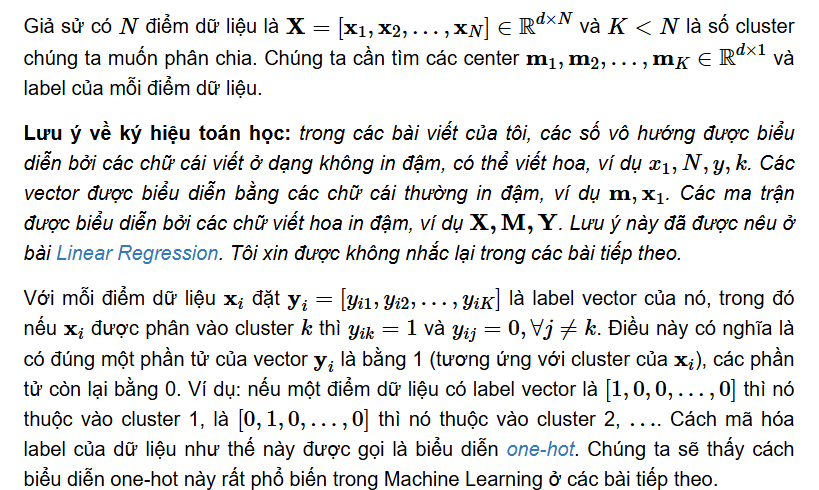

We can understand that x will be data point, y is the label of x, if x belongs to cluster 1 then the first element of y will be 1 and all others will be 0. There will be restrict on y so that it always satisfies the condition.
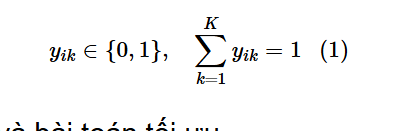

* Loss function and optimized problems
If we consider m_k is center of each cluster and estimate all point divided to this cluster by m_k then a x_i point belong to this cluster will have the loss function: (x_i - m_k). What we have to do is to minimize this equation: 
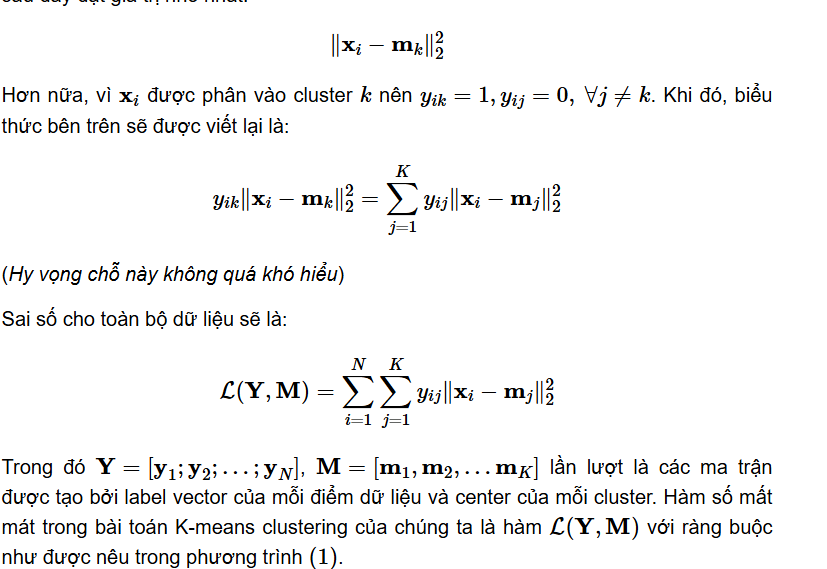

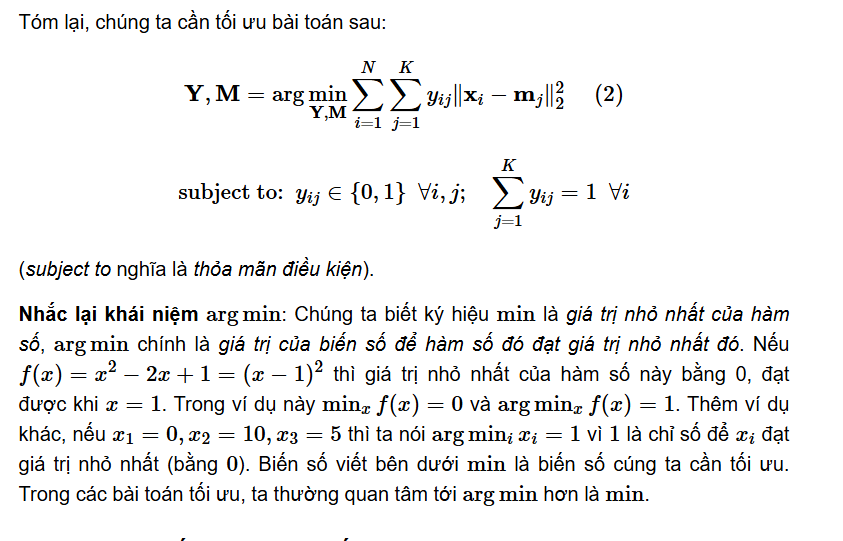
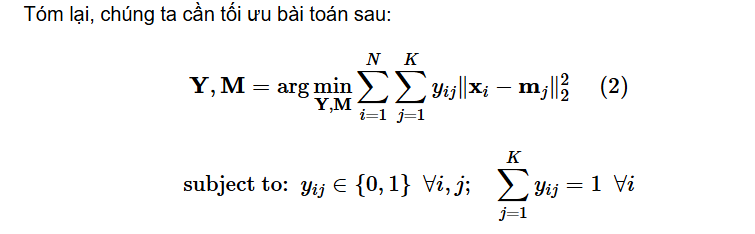

We are not likely to find global optimized point for problem (2) because this problem belong to mix-intergers programming. However, in some cases, we can find way to solve almost-right answer or minimum.
A simple way to solve problem (2) is to alternately optimize ( Y ) and ( M ) while keeping the other variable fixed. This is an iterative algorithm and a common technique for solving optimization problems. We will successively address the following two subproblems:

* Fixed M, find Y
    Assume that we have found centers, find label vectors so that loss function minimized. Or we can call it find cluster for each data point.
    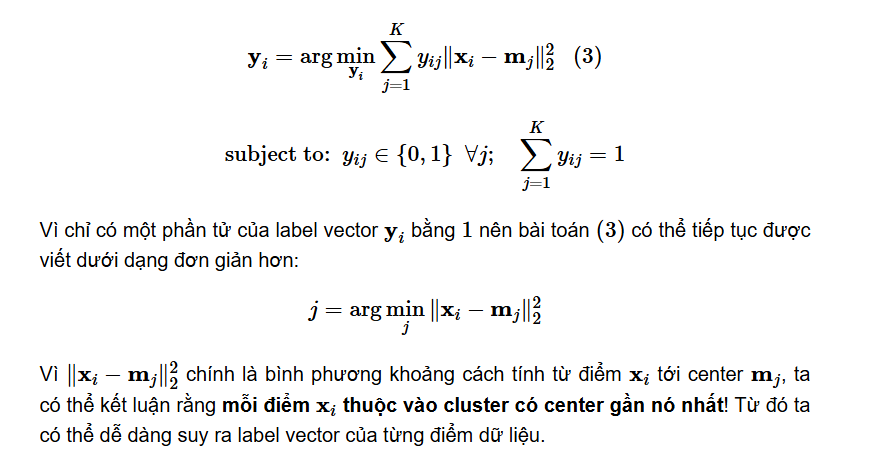



* Fixed Y, find M
    Assume that we have found cluster for each point, find new center for each cluster so that loss function minimized.
    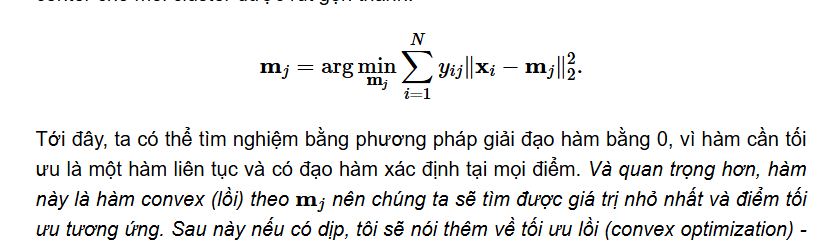

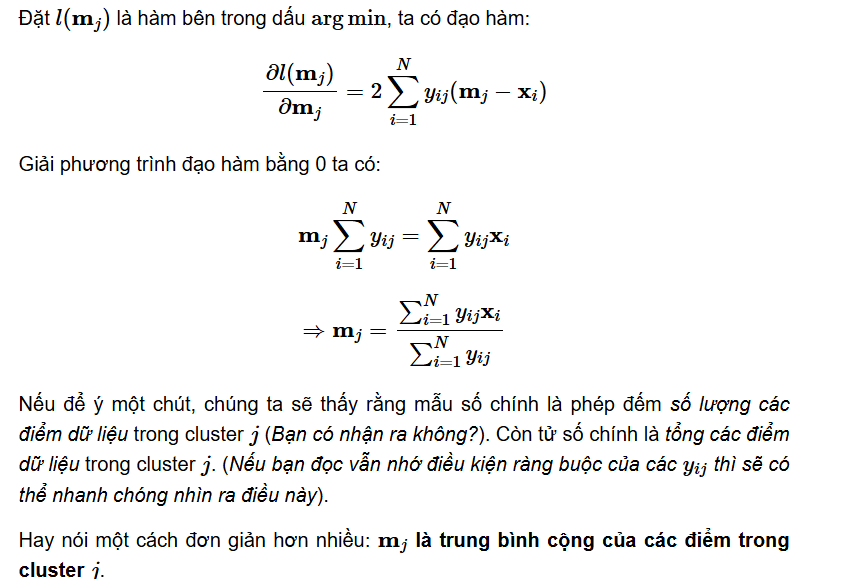

And that how we use Km. 

And to summarize, this is how the algorithm works:

INPUT: Data point X and the number of clusters K
OUTPUT: Centers point M and label vectors Y for each data point.
* 1. Choose K point randomly to be center.
* 2. Divide every X point to the cluster that have nearest center.
* 3. If the assignment of data points to clusters in step 2 does not change compared to the previous iteration, stop the algorithm.
* 4. Update center for all clusters by taking average(mean) of all X point that assigned to the cluster after step 2.
* 5. Return to step 2.

We can sure that the loop is countable because if a sequence is decreasing and bounded below, then it converges.



# 2. Apply in Python
First, we create data by using covariance matrix

In [7]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)

means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 500
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0)
K = 3

original_label = np.asarray([0]*N + [1]*N + [2]*N).T



Next, visualize:

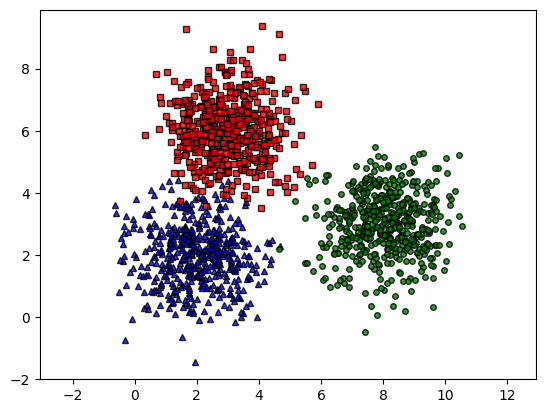

In [8]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8, mec= "black")
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8, mec = 'black')
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8, mec= 'black')

    plt.axis('equal')
    plt.plot()
    plt.show()
    
kmeans_display(X, original_label,   )


Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


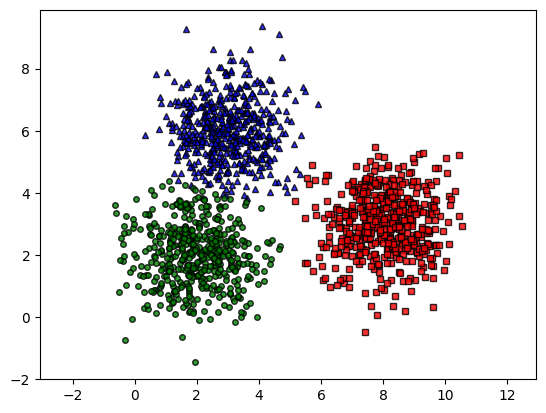

In [ ]:
def kmean_init_centers(X, k):
    # X is all point and k is the number of center
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmean_assign_labels(X, centers):
    #assign label y for x point when know center
    D = cdist(X, centers)
    return np.argmin(D, axis=1)

def kmean_update_centers(X, labels, K):
    #update centers when know labels
    centers = np.zeros((K,X.shape[1]))
    for k in range(K):
        #collect all points in K-clusters
        Xk = X[labels == k, :]
        centers[k, :] = np.mean(Xk, axis=0)
    return centers

def has_converged(centers, new_centers):
    return (set([tuple(a) for a in centers]) == set([tuple(b) for b in new_centers]))

def kmeans(X, K):
    centers = [kmean_init_centers(X,K)]
    labels = []
    it = 0
    while True:
        labels.append(kmean_assign_labels(X,centers[-1]))
        new_centers = kmean_update_centers(X, labels[-1],K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it +=1
    return(centers, labels, it)

(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])

kmeans_display(X, labels[-1])



    








Now we try with scikit-learn

Centers found by scikit-learn:
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


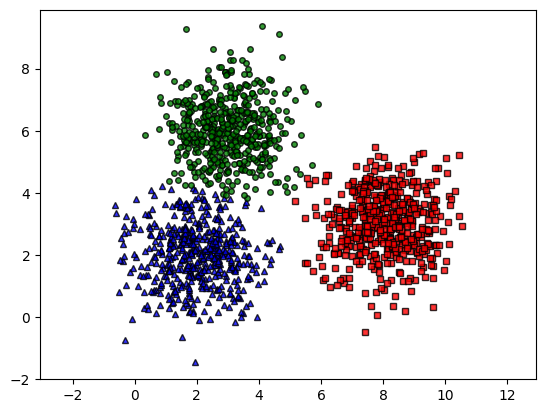

In [10]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

# 3. Drawback
* We have to know numbers of K clusters, in some cases we cannot define it.
* The answer is depends on initial centers, if we get the wrong centers, it will take lots of loops to come to last answer and sometimes only local-minimum
* Clusters need to have nearly equal amount
* Clusters have to be round
* When a clusters is inside another clusters, Km failed